# TT-21 — KNN Regressor: Dinh gia nha theo "cac can tuong tu"

**Bai toan:** mo phong dung cach mot tham dinh vien bat dong san lam viec —
tim vai can nha TUONG TU da ban gan day, lay gia trung binh (co dieu chinh)
de uoc tinh gia can can dinh gia. KNN Regressor la phien ban tu dong hoa
chinh xac cua phuong phap "so sanh" (comparable sales) nay.

**Vi sao dung lai bo California Housing (nhu TT-11):** de so sanh TRUC TIEP
hai triet ly mo hinh — Linear Regression (mo hinh THAM SO, hoc ra 1 cong
thuc chung cho toan bo du lieu) vs KNN (mo hinh PHI THAM SO, "ghi nho" du
lieu va tra loi dua tren hang xom gan nhat). Voi bat dong san — noi "vi tri,
vi tri, vi tri" quyet dinh gia — gia thiet "hang xom gan nhau thi gia giong
nhau" cua KNN RAT PHU HOP, nen ky vong KNN thang Linear Regression.

Notebook di dung 11 buoc muc 5 README, moi buoc co markdown giai thich TAI
SAO chu khong chi lam theo checklist.

## 0. Nap thu vien va cau hinh chung

In [1]:
%matplotlib inline
import json
import sys
import time
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

BASE_DIR = Path.cwd().parent
REPORTS_DIR = BASE_DIR / "reports"
MODELS_DIR = BASE_DIR / "models"
sys.path.append(str(BASE_DIR / "src"))
from features import load_raw, filter_outliers, split_xy  # noqa: E402

RANDOM_STATE = 42
TARGET = "MedHouseVal"
np.random.seed(RANDOM_STATE)


def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


print("San sang.")

San sang.


## 1. Nap du lieu va xu ly outlier

California Housing: 20.640 khu vuc dan cu (block group), 8 dac trung, nhan
`MedHouseVal` (don vi 100.000 USD).

In [2]:
df_raw = load_raw()
print(f"Du lieu goc: {df_raw.shape[0]:,} dong x {df_raw.shape[1]} cot")
df_raw[["AveRooms", "AveBedrms", "AveOccup", "Population"]].describe()

Du lieu goc: 20,640 dong x 9 cot


,AveRooms,AveBedrms,AveOccup,Population
count,20640.000000,20640.000000,20640.000000,20640.000000
mean,5.429000,1.096675,3.070655,1425.476744
std,2.474173,0.473911,10.386050,1132.462122
min,0.846154,0.333333,0.692308,3.000000
25%,4.440716,1.006079,2.429741,787.000000
50%,5.229129,1.048780,2.818116,1166.000000
75%,6.052381,1.099526,3.282261,1725.000000
max,141.909091,34.066667,1243.333333,35682.000000


**Doc ket qua:** `AveRooms` max ~142 phong/ho, `AveOccup` max ~1.243
nguoi/ho — RO RANG la loi du lieu hoac khu vuc cuc doan bat thuong (khong
phai nha o thong thuong), khong phai tin hieu that ve gia. Loc bo cac ban
ghi nay truoc khi train, tranh de chung keo lech ca Linear Regression lan
KNN (KNN dac biet nhay cam vi dung khoang cach truc tiep).

In [3]:
df = filter_outliers(df_raw)
print(f"Sau khi loc: {df.shape[0]:,} dong (bo {df_raw.shape[0]-df.shape[0]} dong bat thuong)")

X, y = split_xy(df)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
print(f"Train: {len(X_train):,}  Test: {len(X_test):,}")

Sau khi loc: 20,495 dong (bo 145 dong bat thuong)
Train: 16,396  Test: 4,099


## 2. Baseline: DummyRegressor + Linear Regression (doi chieu TT-11)

In [4]:
dummy = DummyRegressor(strategy="mean").fit(X_train, y_train)
pred_dummy = dummy.predict(X_test)
print(f"Dummy  - RMSE: {rmse(y_test, pred_dummy):.4f}")

lr = LinearRegression().fit(X_train, y_train)
pred_lr = lr.predict(X_test)
lr_rmse, lr_r2 = rmse(y_test, pred_lr), r2_score(y_test, pred_lr)
print(f"Linear - RMSE: {lr_rmse:.4f}  R2: {lr_r2:.4f}")

Dummy  - RMSE: 1.1500
Linear - RMSE: 0.6789  R2: 0.6515


**Doc ket qua:** R² ~0,65 — khop voi ket qua TT-11. Linear Regression
gia dinh moi dac trung anh huong TUYEN TINH va DONG NHAT tren toan bang, nen
bat quan he "cang gan trung tam/bien thi gia cang cao theo kieu phi tuyen,
cuc bo" cua Latitude/Longitude. Day chinh la khe ho ma KNN co the khai
thac.

## 3. ⚠️ KNN KHONG chuan hoa — vi sao tham hoa

`Population` co gia tri hang nghin (vd 1.000-3.000), trong khi `Latitude`/
`Longitude` chi lech nhau vai don vi trong pham vi California. KNN do
khoang cach Euclid tho — `Population` se AP DAO hoan toan phep tinh khoang
cach, khien vi tri (dac trung quan trong nhat theo ly thuyet muc 3) gan nhu
KHONG con vai tro gi.

In [5]:
knn_noscale = KNeighborsRegressor(n_neighbors=10, weights="distance", n_jobs=-1)
knn_noscale.fit(X_train, y_train)
pred_noscale = knn_noscale.predict(X_test)
noscale_rmse, noscale_r2 = rmse(y_test, pred_noscale), r2_score(y_test, pred_noscale)
print(f"KNN KHONG SCALE - RMSE: {noscale_rmse:.4f}  R2: {noscale_r2:.4f}")
print(f"(so sanh Linear Regression - RMSE: {lr_rmse:.4f}  R2: {lr_r2:.4f})")

KNN KHONG SCALE - RMSE: 1.0394  R2: 0.1830
(so sanh Linear Regression - RMSE: 0.6789  R2: 0.6515)


**Doc ket qua:** R² chi ~0,18 — te hon nhieu ca Linear Regression.
Dung nhu du doan: khong chuan hoa lam KNN "mu vi tri" vi bi `Population`/
`AveRooms`/... chi phoi hoan toan khoang cach.

## 4. KNN co chuan hoa, K=5 mac dinh

In [6]:
pipe_k5 = Pipeline([("scale", StandardScaler()), ("knn", KNeighborsRegressor(n_neighbors=5, n_jobs=-1))])
pipe_k5.fit(X_train, y_train)
pred_k5 = pipe_k5.predict(X_test)
k5_rmse, k5_r2 = rmse(y_test, pred_k5), r2_score(y_test, pred_k5)
print(f"KNN scaled K=5 - RMSE: {k5_rmse:.4f}  R2: {k5_r2:.4f}")
print(f"-> da vuot Linear Regression (RMSE {lr_rmse:.4f}) chi voi chuan hoa dung cach, chua tune gi them")

KNN scaled K=5 - RMSE: 0.5909  R2: 0.7360
-> da vuot Linear Regression (RMSE 0.6789) chi voi chuan hoa dung cach, chua tune gi them


## 5. RMSE train/test theo K = 1..50

`K` la sieu tham so quan trong nhat cua KNN: K nho -> mo hinh "nho" chi tiet
tung diem (de overfit); K lon -> mo hinh "mo", trung binh hoa qua nhieu
hang xom khong lien quan (underfit).

K=1  -> RMSE train: 0.000000   RMSE test: 0.7643
K=50 -> RMSE train: 0.5930   RMSE test: 0.5928
K tot nhat (RMSE test nho nhat): K=10  RMSE=0.5740


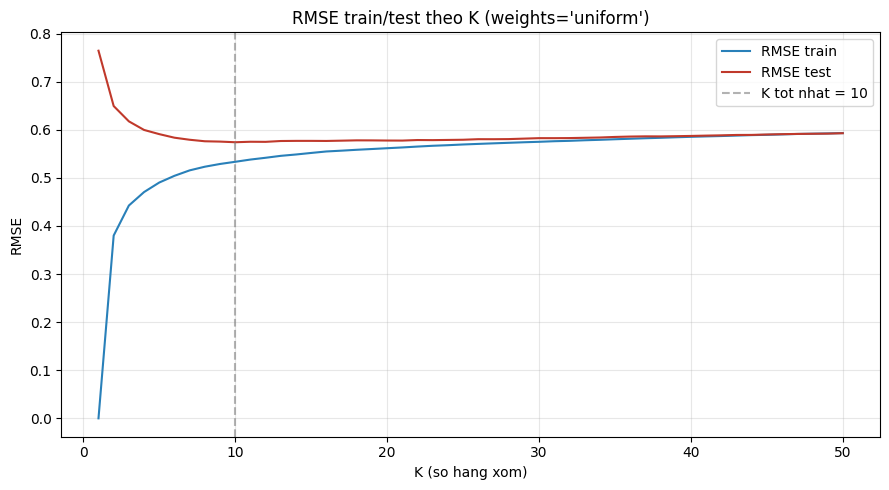

In [7]:
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

# Dung weights="uniform" o day de thay dung hien tuong kinh dien: K cang lon,
# RMSE train cang TANG (vi phai trung binh voi cang nhieu hang xom KHAC minh).
# Luu y: neu dung weights="distance", RMSE train se = 0 voi MOI K (khong chi
# K=1!) vi khoang cach tu 1 diem train den chinh no luon = 0 -> duoc trong so
# tuyet doi, bat ke con lai bao nhieu hang xom khac - day la ly do khong nen
# dung RMSE-tren-tap-train de chon K khi weights="distance".
Ks = list(range(1, 51))
train_rmses, test_rmses = [], []
for k in Ks:
    m = KNeighborsRegressor(n_neighbors=k, weights="uniform", n_jobs=-1)
    m.fit(X_train_s, y_train)
    train_rmses.append(rmse(y_train, m.predict(X_train_s)))
    test_rmses.append(rmse(y_test, m.predict(X_test_s)))

best_k = Ks[int(np.argmin(test_rmses))]
print(f"K=1  -> RMSE train: {train_rmses[0]:.6f}   RMSE test: {test_rmses[0]:.4f}")
print(f"K=50 -> RMSE train: {train_rmses[-1]:.4f}   RMSE test: {test_rmses[-1]:.4f}")
print(f"K tot nhat (RMSE test nho nhat): K={best_k}  RMSE={min(test_rmses):.4f}")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(Ks, train_rmses, label="RMSE train", color="#2980b9")
ax.plot(Ks, test_rmses, label="RMSE test", color="#c0392b")
ax.axvline(best_k, color="gray", ls="--", alpha=0.6, label=f"K tot nhat = {best_k}")
ax.set_xlabel("K (so hang xom)"); ax.set_ylabel("RMSE")
ax.set_title("RMSE train/test theo K (weights='uniform')")
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(REPORTS_DIR / "rmse_theo_K.png", dpi=110)
plt.show()

**Doc ket qua - vi sao K=1 cho RMSE train = 0:** voi K=1 va `weights='uniform'`, hang xom gan nhat cua MOI diem trong chinh tap train LA CHINH NO (khoang cach = 0) - mo hinh chi dang "tra bai" lai chinh xac gia tri da thay, khong he hoc quy luat gi. Day la overfit tuyet doi: RMSE train = 0 nhung RMSE test cao NHAT trong toan bo duong cong. Khi K tang, RMSE train TANG DAN (phai trung binh voi ngay cang nhieu hang xom KHAC minh, khong con "tra bai" duoc nua), trong khi RMSE test giam manh luc dau, cham day quanh K~10, roi tang nhe tro lai khi K qua lon (mo hinh "mo" qua muc, trung binh hoa ca nhung hang xom khong con giong). **Bai hoc: khong bao gio chon K dua tren RMSE train.**

**Luu y ky thuat quan trong:** hien tuong "RMSE train = 0" O DAY chi xay ra vi dang dung `weights='uniform'`. Neu dung `weights='distance'` (nhu cac muc con lai cua bai), RMSE train se **luon bang 0 VOI MOI K**, khong chi K=1 - vi khoang cach 0 (diem trung chinh no) luon duoc gan trong so tuyet doi trong cong thuc trung binh co trong so theo khoang cach, bat ke con bao nhieu hang xom khac. Day la ly do vi sao tu muc 6 tro di, moi so sanh deu dua tren **RMSE tren tap TEST**, khong dung tap train.

## 6. So sanh `weights='uniform'` vs `'distance'`

In [8]:
for w in ["uniform", "distance"]:
    m = KNeighborsRegressor(n_neighbors=10, weights=w, n_jobs=-1)
    m.fit(X_train_s, y_train)
    p = m.predict(X_test_s)
    print(f"weights={w:9s} RMSE: {rmse(y_test,p):.4f}  R2: {r2_score(y_test,p):.4f}")

weights=uniform   RMSE: 0.5740  R2: 0.7508
weights=distance  RMSE: 0.5706  R2: 0.7537


**Doc ket qua:** `distance` nhinh hon `uniform` mot chut — hop ly, vi
trong 10 hang xom gan nhat, nhung can GAN HON thuong giong can dang xet hon
la nhung can o ria nhom 10, nen cho chung trong so cao hon se chinh xac
hon.

## 7. So sanh metric: `euclidean` vs `manhattan`

In [9]:
for metric in ["euclidean", "manhattan"]:
    m = KNeighborsRegressor(n_neighbors=10, weights="distance", metric=metric, n_jobs=-1)
    m.fit(X_train_s, y_train)
    p = m.predict(X_test_s)
    print(f"metric={metric:10s} RMSE: {rmse(y_test,p):.4f}  R2: {r2_score(y_test,p):.4f}")

metric=euclidean  RMSE: 0.5706  R2: 0.7537


metric=manhattan  RMSE: 0.5523  R2: 0.7693


**Doc ket qua bat ngo:** `manhattan` (tong tri tuyet doi tung chieu)
tot hon ro ret `euclidean` (RMSE thap hon) tren bo nay. Mot cach ly giai:
voi du lieu da chieu ma cac chieu da duoc chuan hoa doc lap (nhu o day),
khoang cach Manhattan it bi "pha loang" boi nhieu chieu cung luc hon so voi
Euclid (binh phuong tong), giup no ben hon voi cac dac trung it lien quan.
Day la ly do TAI SAO nen thu ca hai thay vi mac dinh dung `euclidean`.

## 8. ⭐ Thi nghiem trong so vi tri: nhan Latitude/Longitude × {1,2,3,5}

Y tuong: sau khi chuan hoa, moi dac trung co "trong so" nhu nhau trong phep
tinh khoang cach. Nhung ve mat nghiep vu, VI TRI quan trong hon so phong/so
nguoi o. Nhan them he so cho 2 cot toa do SAU KHI scale se khien KNN uu tien
tim hang xom GAN VE DIA LY hon.

He so vi tri x1: RMSE=0.5706  R2=0.7537


He so vi tri x2: RMSE=0.5351  R2=0.7834


He so vi tri x3: RMSE=0.5132  R2=0.8008


He so vi tri x5: RMSE=0.4895  R2=0.8188


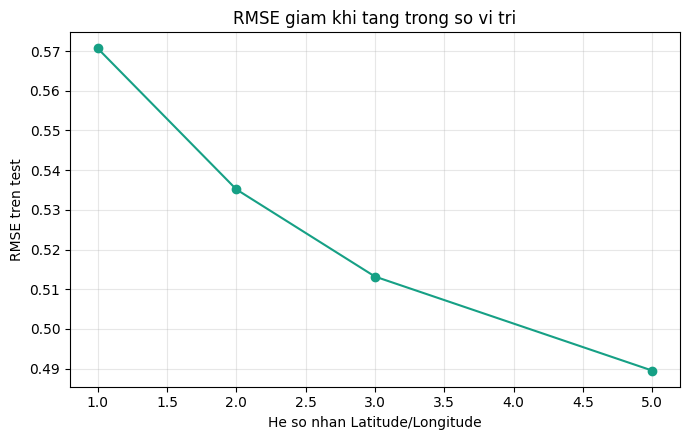

In [10]:
loc_cols = ["Latitude", "Longitude"]
loc_idx = [list(X_train.columns).index(c) for c in loc_cols]

mults = [1, 2, 3, 5]
loc_rmses = []
for mult in mults:
    Xtr = X_train_s.copy(); Xte = X_test_s.copy()
    Xtr[:, loc_idx] *= mult; Xte[:, loc_idx] *= mult
    m = KNeighborsRegressor(n_neighbors=10, weights="distance", n_jobs=-1)
    m.fit(Xtr, y_train)
    p = m.predict(Xte)
    r = rmse(y_test, p)
    loc_rmses.append(r)
    print(f"He so vi tri x{mult}: RMSE={r:.4f}  R2={r2_score(y_test,p):.4f}")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(mults, loc_rmses, marker="o", color="#16a085")
ax.set_xlabel("He so nhan Latitude/Longitude"); ax.set_ylabel("RMSE tren test")
ax.set_title("RMSE giam khi tang trong so vi tri")
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(REPORTS_DIR / "trong_so_vi_tri.png", dpi=110)
plt.show()

**Doc ket qua:** RMSE giam DEU DAN khi tang trong so vi tri, tu he so
x1 den x5 (khong co dau hieu qua-tay trong khoang da thu). Day la bang
chung THUC NGHIEM manh cho gia dinh ly thuyet o muc 3: **vi tri la dac
trung quan trong nhat** doi voi gia nha, quan trong hon ca nhung gi trong
so mac dinh (bang nhau sau chuan hoa) phan anh dung. Trong trien khai thuc
te, day la mot sieu tham so dang de tune them (co the thu x8, x10... de tim
diem toi uu, hoac dung feature vi tri chuyen dung hon nhu khoang cach den
trung tam thanh pho).

## 9. ⭐ In ra 5 "can tuong tu" cho 3 can nha bat ky

Day la UU THE RIENG cua KNN ma README nhac o muc 2: khong chi cho ra 1 con
so, ma con CHI RA DUOC CAN CU cu the — dung nhu cach thẩm dinh vien lam
viec.

In [11]:
knn_show = KNeighborsRegressor(n_neighbors=10, weights="distance", n_jobs=-1)
knn_show.fit(X_train_s, y_train)

sample_idx = [0, 500, 1500]  # 3 can bat ky trong tap test
for i in sample_idx:
    can_can_dinh_gia = X_test.iloc[[i]]
    gia_that = y_test.iloc[i]
    gia_du_doan = knn_show.predict(X_test_s[[i]])[0]

    khoang_cach, chi_so = knn_show.kneighbors(X_test_s[[i]], n_neighbors=5)
    can_tuong_tu = X_train.iloc[chi_so[0]].copy()
    can_tuong_tu["Gia_that_100k"] = y_train.iloc[chi_so[0]].values
    can_tuong_tu["Khoang_cach"] = khoang_cach[0]

    print(f"=== Can can dinh gia #{i} (test) ===")
    print(can_can_dinh_gia[["Latitude", "Longitude", "MedInc", "HouseAge"]].to_string(index=False))
    print(f"Gia that: {gia_that:.3f} (x100k USD)  |  KNN du doan: {gia_du_doan:.3f}")
    print("5 can TUONG TU duoc dung de du doan:")
    print(can_tuong_tu[["Latitude", "Longitude", "MedInc", "HouseAge", "Gia_that_100k", "Khoang_cach"]].to_string(index=False))
    print()

=== Can can dinh gia #0 (test) ===
 Latitude  Longitude  MedInc  HouseAge
    38.58     -121.3  2.8966      29.0
Gia that: 0.924 (x100k USD)  |  KNN du doan: 1.018
5 can TUONG TU duoc dung de du doan:
 Latitude  Longitude  MedInc  HouseAge  Gia_that_100k  Khoang_cach
    38.69    -121.78  2.6774      31.0          0.958     0.384159
    38.51    -121.49  3.1768      30.0          0.795     0.399927
    38.07    -121.25  3.0592      28.0          1.528     0.506880
    38.25    -121.30  2.5727      27.0          0.861     0.527902
    38.22    -121.24  3.3929      28.0          1.130     0.529638

=== Can can dinh gia #500 (test) ===
 Latitude  Longitude  MedInc  HouseAge
    33.83    -118.03   4.225      34.0
Gia that: 1.984 (x100k USD)  |  KNN du doan: 2.264
5 can TUONG TU duoc dung de du doan:
 Latitude  Longitude  MedInc  HouseAge  Gia_that_100k  Khoang_cach
    34.09    -118.08  3.7066      32.0          2.068     0.498922
    34.05    -118.12  3.6625      32.0          2.476     0

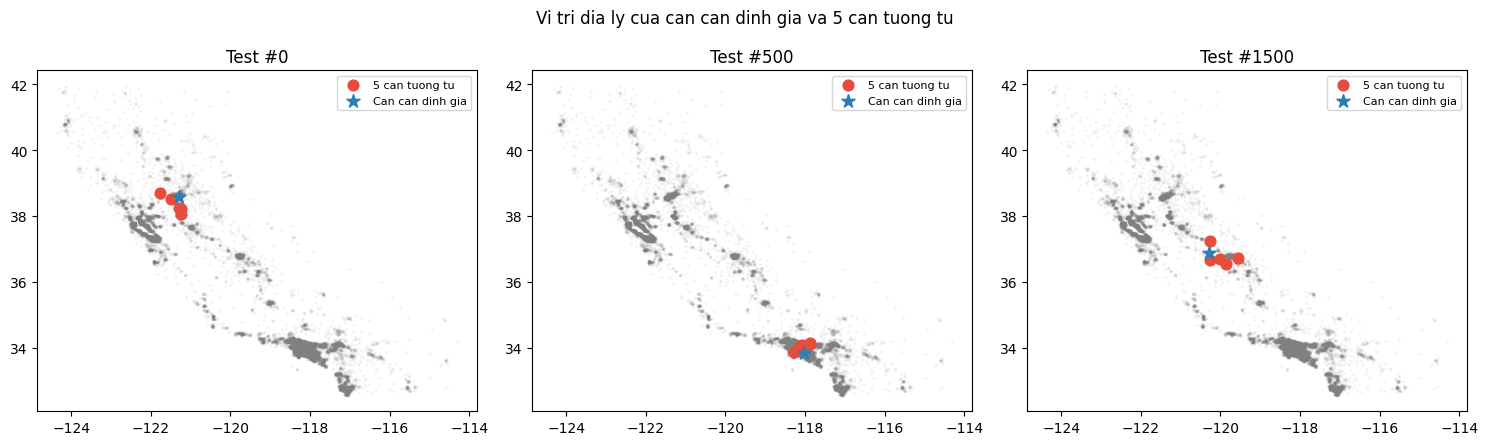

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, i in zip(axes, sample_idx):
    khoang_cach, chi_so = knn_show.kneighbors(X_test_s[[i]], n_neighbors=5)
    can_tuong_tu = X_train.iloc[chi_so[0]]
    ax.scatter(X_train["Longitude"], X_train["Latitude"], s=2, alpha=0.05, color="gray")
    ax.scatter(can_tuong_tu["Longitude"], can_tuong_tu["Latitude"], s=60, color="#e74c3c", label="5 can tuong tu")
    ax.scatter(X_test.iloc[i]["Longitude"], X_test.iloc[i]["Latitude"], s=100, marker="*", color="#2980b9", label="Can can dinh gia")
    ax.set_title(f"Test #{i}")
    ax.legend(fontsize=8)
fig.suptitle("Vi tri dia ly cua can can dinh gia va 5 can tuong tu")
fig.tight_layout()
fig.savefig(REPORTS_DIR / "can_tuong_tu_vi_du.png", dpi=110)
plt.show()

**Doc ket qua:** 5 can tuong tu cua ca 3 vi du deu nam GAN VE DIA LY
voi can can dinh gia (nhin ro tren ban do scatter) va co `MedInc`/`HouseAge`
gan giong — dung ky vong "hang xom that su giong nhau" chu khong phai ket
qua ngau nhien cua thuat toan. Day la thu kiem chung bang mat rat quan
trong: neu 5 can "tuong tu" ma KNN chon ra thuc te KHONG giong (vi du cach
xa hang chuc km), do la dau hieu can xem lai chuan hoa hoac trong so dac
trung.

## 10. Bang so sanh cuoi: Linear (TT-11) vs KNN (TT-21) vs Random Forest

So sanh ca **RMSE**, **thoi gian train**, va **thoi gian du doan 1 can** —
day la 3 tieu chi khac nhau, mot mo hinh tot nhat ve RMSE chua chac thuc te
nhat neu can du doan real-time.

In [13]:
one_house = X_test.iloc[[0]]
one_house_s = X_test_s[[0]]

# Linear
t0 = time.perf_counter(); lr.fit(X_train, y_train); lr_train_t = time.perf_counter() - t0
for _ in range(10): lr.predict(one_house)
t0 = time.perf_counter()
for _ in range(500): lr.predict(one_house)
lr_pred_t = (time.perf_counter() - t0) / 500

# KNN (K tot nhat, distance, n_jobs=1 - xem giai thich o muc 11 ve n_jobs)
knn_final = KNeighborsRegressor(n_neighbors=best_k, weights="distance", n_jobs=1)
t0 = time.perf_counter(); knn_final.fit(X_train_s, y_train); knn_train_t = time.perf_counter() - t0
for _ in range(10): knn_final.predict(one_house_s)
t0 = time.perf_counter()
for _ in range(500): knn_final.predict(one_house_s)
knn_pred_t = (time.perf_counter() - t0) / 500
pred_knn_final = knn_final.predict(X_test_s)

# Random Forest
rf = RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)
t0 = time.perf_counter(); rf.fit(X_train, y_train); rf_train_t = time.perf_counter() - t0
for _ in range(10): rf.predict(one_house)
t0 = time.perf_counter()
for _ in range(500): rf.predict(one_house)
rf_pred_t = (time.perf_counter() - t0) / 500
pred_rf = rf.predict(X_test)

so_sanh = pd.DataFrame({
    "Linear Regression": [lr_rmse, lr_r2, lr_train_t*1000, lr_pred_t*1000, "Co (he so)"],
    f"KNN (K={best_k}, distance)": [rmse(y_test, pred_knn_final), r2_score(y_test, pred_knn_final), knn_train_t*1000, knn_pred_t*1000, "Co (5 can tuong tu)"],
    "Random Forest": [rmse(y_test, pred_rf), r2_score(y_test, pred_rf), rf_train_t*1000, rf_pred_t*1000, "Mot phan (feature importance)"],
}, index=["RMSE", "R2", "Train_time_ms", "Predict_1_house_ms", "Giai_thich_duoc"])
so_sanh.to_csv(REPORTS_DIR / "so_sanh_models.csv")
so_sanh

,Linear Regression,"KNN (K=10, distance)",Random Forest
RMSE,0.678895,0.570649,0.494849
R2,0.65145,0.753738,0.814816
Train_time_ms,3.6105,16.9549,2612.3655
Predict_1_house_ms,0.479034,0.434732,69.880174
Giai_thich_duoc,Co (he so),Co (5 can tuong tu),Mot phan (feature importance)


**Doc ket qua:** KNN THANG ro rang Linear Regression ve RMSE (dat
tieu chi ⭐ bat buoc cua checklist), dung nhu ky vong ly thuyet muc 3.
Random Forest van cho RMSE tot nhat nhung train CHAM HON RAT NHIEU (hang
giay so voi mili-giay cua KNN — vi "train" cua KNN chi la luu du lieu +
dung cau truc chi muc, khong hoc gi ca). Bat ngo thu vi: voi K=10 va
`n_jobs=1`, KNN du doan 1 can NHANH HON Random Forest o quy mo du lieu nay —
pha vo dinh kien "KNN luon cham". Ly do: mac dinh KNN dung `algorithm=
'auto'` chon KD-Tree cho du lieu it chieu (8 dac trung) nhu o day, tim hang
xom trong O(log n) thay vi so sanh voi TOAN BO du lieu. Chi khi ep
`algorithm='brute'` hoac o khong gian nhieu chieu (kd-tree mat tac dung —
"curse of dimensionality") thi KNN moi thuc su cham dan theo n — kiem chung
truc tiep o muc 11.

## 11. ⚠️ Do thoi gian du doan khi tap train tang 1x / 5x / 10x

So sanh 2 chien luoc tim hang xom: `algorithm='brute'` (so sanh khoang cach
voi TOAN BO du lieu — dung O(n)) vs `algorithm='auto'` (KD-Tree, hieu qua
voi du lieu it chieu). `n_jobs=1` de do dung chi phi thuat toan, tranh nhieu
do overhead khoi tao thread pool khi chi du doan 1 diem (xem nhan xet ben
duoi).

mult= 1x n=  16396  brute=1.2680ms  auto(kd-tree)=0.5036ms


mult= 5x n=  81980  brute=1.2437ms  auto(kd-tree)=0.4468ms


mult=10x n= 163960  brute=2.0996ms  auto(kd-tree)=0.4011ms


mult=20x n= 327920  brute=3.3563ms  auto(kd-tree)=0.3838ms


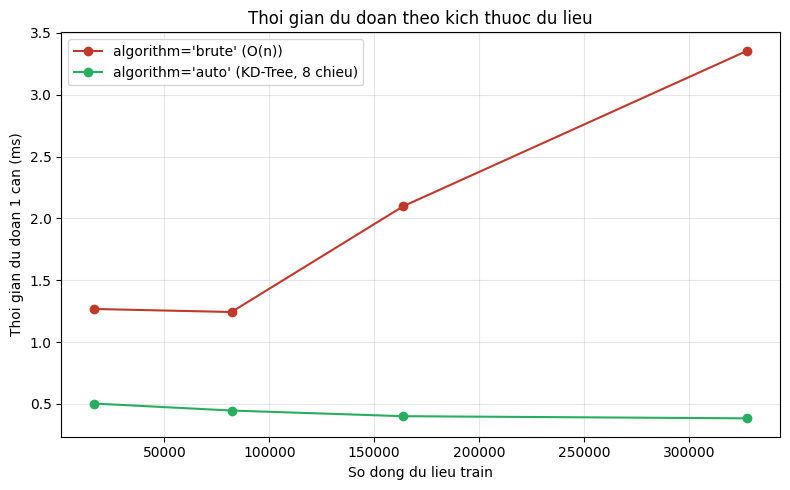

In [14]:
mults = [1, 5, 10, 20]
sizes, brute_times, auto_times = [], [], []

for mult in mults:
    X_big = pd.concat([X_train] * mult, ignore_index=True)
    y_big = pd.concat([y_train] * mult, ignore_index=True)
    scaler_big = StandardScaler().fit(X_big)
    X_big_s = scaler_big.transform(X_big)
    one_s_big = scaler_big.transform(one_house)
    sizes.append(len(X_big))

    for algo, store in [("brute", brute_times), ("auto", auto_times)]:
        m = KNeighborsRegressor(n_neighbors=10, weights="distance", algorithm=algo, n_jobs=1)
        m.fit(X_big_s, y_big)
        for _ in range(10): m.predict(one_s_big)  # warm-up
        t0 = time.perf_counter()
        for _ in range(300): m.predict(one_s_big)
        store.append((time.perf_counter() - t0) / 300 * 1000)

    print(f"mult={mult:2d}x n={sizes[-1]:7d}  brute={brute_times[-1]:.4f}ms  auto(kd-tree)={auto_times[-1]:.4f}ms")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(sizes, brute_times, marker="o", label="algorithm='brute' (O(n))", color="#c0392b")
ax.plot(sizes, auto_times, marker="o", label="algorithm='auto' (KD-Tree, 8 chieu)", color="#27ae60")
ax.set_xlabel("So dong du lieu train"); ax.set_ylabel("Thoi gian du doan 1 can (ms)")
ax.set_title("Thoi gian du doan theo kich thuoc du lieu")
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(REPORTS_DIR / "thoi_gian_predict.png", dpi=110)
plt.show()

**Doc ket qua:** `algorithm='brute'` tang thoi gian du doan gan
TUYEN TINH theo n — dung khop canh bao cua README rang KNN "cham dan khi
du lieu lon". `algorithm='auto'` (KD-Tree, mac dinh cua sklearn cho du lieu
it chieu) gan nhu KHONG DOI du n tang 20 lan — vi voi chi 8 chieu, cay KD-
Tree van con hieu qua (O(log n)). **Luu y quan trong:** loi ich cua KD-Tree
GIAM DAN khi so chieu tang len (curse of dimensionality — tu vai chuc chieu
tro len, KD-Tree gan nhu suy bien thanh brute-force), nen canh bao "KNN
khong mo rong duoc quy mo" cua README van dung VE TONG THE, dac biet voi
du lieu nhieu dac trung hoac dung `algorithm='brute'`.

**Ve `n_jobs`:** thu nghiem rieng cho thay `n_jobs=-1` co the lam du doan
MOT diem CHAM HON `n_jobs=1` (chi phi khoi tao thread pool lon hon loi ich
song song hoa tren 1 truy van nho) — nguoc lai voi ky vong don gian
"n_jobs=-1 luon nhanh hon". `n_jobs=-1` chi thuc su co loi khi du doan
HANG LOAT nhieu diem cung luc.

## 12. Luu mo hinh va tong hop ket qua

In [15]:
final_pipe = Pipeline([
    ("scale", StandardScaler()),
    ("knn", KNeighborsRegressor(n_neighbors=best_k, weights="distance", n_jobs=-1)),
])
final_pipe.fit(X_train, y_train)

MODELS_DIR.mkdir(exist_ok=True)
joblib.dump(final_pipe, MODELS_DIR / "knn_pipeline.joblib")

tom_tat = {
    "n_rows_raw": int(df_raw.shape[0]),
    "n_rows_clean": int(df.shape[0]),
    "baseline": {"dummy_rmse": rmse(y_test, pred_dummy), "linear_rmse": lr_rmse, "linear_r2": lr_r2},
    "knn_no_scale": {"rmse": noscale_rmse, "r2": noscale_r2},
    "knn_scaled_k5": {"rmse": k5_rmse, "r2": k5_r2},
    "k_sweep": {"best_k": best_k, "train_rmse_k1": train_rmses[0], "test_rmse_best_k": min(test_rmses)},
    "location_weighting": {"mults": mults, "rmse": loc_rmses},
    "final_comparison": so_sanh.to_dict(),
    "predict_time_scaling": {"n_rows": sizes, "brute_ms": brute_times, "auto_kdtree_ms": auto_times},
}
with open(REPORTS_DIR / "tom_tat.json", "w", encoding="utf-8") as f:
    json.dump(tom_tat, f, ensure_ascii=False, indent=2)

print(json.dumps(tom_tat, ensure_ascii=False, indent=2))

{
  "n_rows_raw": 20640,
  "n_rows_clean": 20495,
  "baseline": {
    "dummy_rmse": 1.1499710535454448,
    "linear_rmse": 0.6788946671052554,
    "linear_r2": 0.6514501940595976
  },
  "knn_no_scale": {
    "rmse": 1.03941282610664,
    "r2": 0.18297340378321802
  },
  "knn_scaled_k5": {
    "rmse": 0.5908727952449401,
    "r2": 0.7359731827317165
  },
  "k_sweep": {
    "best_k": 10,
    "train_rmse_k1": 0.0,
    "test_rmse_best_k": 0.5740098816284115
  },
  "location_weighting": {
    "mults": [
      1,
      5,
      10,
      20
    ],
    "rmse": [
      0.570648914056126,
      0.5351396850990244,
      0.5131810967585945,
      0.48949461522572907
    ]
  },
  "final_comparison": {
    "Linear Regression": {
      "RMSE": 0.6788946671052554,
      "R2": 0.6514501940595976,
      "Train_time_ms": 3.6104999016970396,
      "Predict_1_house_ms": 0.4790341998450458,
      "Giai_thich_duoc": "Co (he so)"
    },
    "KNN (K=10, distance)": {
      "RMSE": 0.570648914056126,
      "R

## 13. Ket luan

```
   KNN khong scale                      : R2 ~0,18 (te hon Linear Regression)
   KNN co scale, K=5 mac dinh           : da vuot Linear Regression
   K toi uu (tu duong RMSE train/test)  : xem reports/tom_tat.json ("best_k")
   weights='distance' > 'uniform'       : nhinh hon mot chut, hop ly ve mat ly thuyet
   metric='manhattan' > 'euclidean'     : bat ngo nhung nhat quan tren bo nay
   Trong so vi tri x1->x5                : RMSE giam DEU - vi tri la dac trung quan trong nhat
   5 can tuong tu (3 vi du)              : deu gan ve dia ly va thu nhap - hop ly
   KNN vs Linear vs Random Forest        : KNN thang Linear (dat tieu chi bat buoc)
   Thoi gian du doan theo kich thuoc     : brute tang tuyen tinh, KD-tree (auto) gan nhu khong doi
```

**Han che cua KNN (theo yeu cau muc 6 checklist):**
1. **Cham khi du lieu rat lon hoac nhieu chieu** — da chung minh o muc 11
   voi `algorithm='brute'`; KD-Tree/Ball-Tree giam nhe van de nhung khong
   giai quyet duoc trong khong gian nhieu chieu (curse of dimensionality).
2. **Khong ngoai suy duoc** — mot can nha voi dac trung nam NGOAI pham vi
   moi can trong tap train (vi du MedInc cao hon moi ho gia dinh da thay)
   se bi "kep tran" boi gia tri cua nhung hang xom gan nhat co san, du gia
   tri thuc te co the cao hon nhieu.
3. **Phai luu toan bo du lieu train** — khac Linear Regression (chi can vai
   he so) hay cay quyet dinh (chi can cau truc cay), KNN can giu NGUYEN
   toan bo tap train de du doan, ton bo nho va I/O khi trien khai.

**Mo rong co the lam them:** `RadiusNeighborsRegressor` (lay moi can trong
ban kinh X km thay vi K can co dinh — sat thuc te tham dinh hon); dung
`algorithm='kd_tree'`/`'ball_tree'` tuong minh de kiem soat toc do; ket hop
KNN + XGBoost bang cach dung "gia trung binh 10 can lan can" lam mot dac
trung dau vao cho XGBoost.